<a href="https://colab.research.google.com/github/Harshada-Navghane/Python-assignment/blob/main/Telecome_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [ ]:
df=pd.read_csv("Telecom Dataset.csv")

In [ ]:
print(df.head(10))

       PID Blue Wi_Fi Tch_Scr Ext_Mem  ...  Bty_Pwr  RAM  Depth  Weight  Price
0  AAB346A  yes   yes      no      no  ...     2800    2      7     320   3297
1  AAC347I  yes   yes      no      no  ...     3000    2      7     280   4500
2  BAB657J   no   yes      no      no  ...     3300    2      7     400   4898
3  BBD456K   no   yes     yes      no  ...     3000    2      3     300   6900
4  CCP761U   no   yes     yes      no  ...     3000    2      3     210   5600
5  CCQ674K  yes    no      no      no  ...     2980    2      3     230   4990
6  CTX123L  yes    no     yes      no  ...     3000    2      3     100  13400
7  DFR256N  yes    no      no      no  ...     3200    2      3      80  15600
8  DGS789M  yes   yes     yes     yes  ...     2800    6      3     120  27688
9  ENG897N  yes   yes     yes     yes  ...     4380    4      3     150  23456

[10 rows x 17 columns]


In [ ]:
df.shape

(50, 17)

In [ ]:
df.index

RangeIndex(start=0, stop=50, step=1)

In [ ]:
df.columns

Index(['PID', 'Blue', 'Wi_Fi', 'Tch_Scr', 'Ext_Mem', 'Px_h', 'Px_w', 'Scr_h',
       'Scr_w', 'PC', 'FC', 'Int_Mem', 'Bty_Pwr', 'RAM', 'Depth', 'Weight',
       'Price'],
      dtype='object')

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   PID      50 non-null     object
 1   Blue     50 non-null     object
 2   Wi_Fi    50 non-null     object
 3   Tch_Scr  50 non-null     object
 4   Ext_Mem  50 non-null     object
 5   Px_h     50 non-null     int64 
 6   Px_w     50 non-null     int64 
 7   Scr_h    50 non-null     int64 
 8   Scr_w    50 non-null     int64 
 9   PC       50 non-null     int64 
 10  FC       50 non-null     int64 
 11  Int_Mem  50 non-null     int64 
 12  Bty_Pwr  50 non-null     int64 
 13  RAM      50 non-null     int64 
 14  Depth    50 non-null     int64 
 15  Weight   50 non-null     int64 
 16  Price    50 non-null     int64 
dtypes: int64(12), object(5)
memory usage: 6.8+ KB
None


In [ ]:
print(df.describe())

              Px_h         Px_w  ...      Weight          Price
count    50.000000    50.000000  ...   50.000000      50.000000
mean   2319.400000  1833.200000  ...  195.200000   33794.860000
std     598.400623   469.713069  ...   75.761171   25037.535393
min     780.000000   460.000000  ...   80.000000    3297.000000
25%    2080.000000  1775.000000  ...  142.500000   19126.500000
50%    2580.000000  1980.000000  ...  190.000000   29349.500000
75%    2580.000000  2120.000000  ...  247.500000   43560.000000
max    2880.000000  2520.000000  ...  400.000000  149000.000000

[8 rows x 12 columns]


In [ ]:
print(df.isnull().sum())

PID        0
Blue       0
Wi_Fi      0
Tch_Scr    0
Ext_Mem    0
Px_h       0
Px_w       0
Scr_h      0
Scr_w      0
PC         0
FC         0
Int_Mem    0
Bty_Pwr    0
RAM        0
Depth      0
Weight     0
Price      0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.mean(numeric_only=True))

Px_h        2319.40
Px_w        1833.20
Scr_h          6.50
Scr_w          4.62
PC            42.16
FC            20.76
Int_Mem      173.76
Bty_Pwr     3740.00
RAM            5.76
Depth          3.44
Weight       195.20
Price      33794.86
dtype: float64


In [ ]:
print(df.median(numeric_only=True))

Px_h        2580.0
Px_w        1980.0
Scr_h          6.0
Scr_w          5.0
PC            40.0
FC            16.0
Int_Mem       64.0
Bty_Pwr     3300.0
RAM            5.0
Depth          3.0
Weight       190.0
Price      29349.5
dtype: float64


In [ ]:
print(df.mode(numeric_only=True))

     Px_h    Px_w  Scr_h  Scr_w    PC  ...  Bty_Pwr  RAM  Depth  Weight    Price
0  2580.0  1980.0    8.0    6.0  64.0  ...   2800.0  8.0    3.0     150  23456.0
1     NaN     NaN    NaN    NaN   NaN  ...      NaN  NaN    NaN     210      NaN

[2 rows x 12 columns]


In [ ]:
print(df.var(numeric_only=True))

Px_h       3.580833e+05
Px_w       2.206304e+05
Scr_h      4.173469e+00
Scr_w      3.546531e+00
PC         9.105045e+02
FC         2.185943e+02
Int_Mem    6.852451e+04
Bty_Pwr    9.193306e+05
RAM        7.614694e+00
Depth      1.108571e+00
Weight     5.739755e+03
Price      6.268782e+08
dtype: float64


In [ ]:
print(df.std(numeric_only=True))

Px_h         598.400623
Px_w         469.713069
Scr_h          2.042907
Scr_w          1.883223
PC            30.174567
FC            14.784934
Int_Mem      261.771871
Bty_Pwr      958.817299
RAM            2.759473
Depth          1.052887
Weight        75.761171
Price      25037.535393
dtype: float64


In [ ]:
print(df['Blue'].value_counts())
print(df['Wi_Fi'].value_counts())
print(df['Tch_Scr'].value_counts())
print(df['Ext_Mem'].value_counts())

Blue
yes    27
no     23
Name: count, dtype: int64
Wi_Fi
yes    42
no      8
Name: count, dtype: int64
Tch_Scr
yes    45
no      5
Name: count, dtype: int64
Ext_Mem
yes    38
no     12
Name: count, dtype: int64


             Px_h      Px_w     Scr_h  ...     Depth    Weight     Price
Px_h     1.000000  0.962988  0.619936  ... -0.555409 -0.394854  0.546202
Px_w     0.962988  1.000000  0.651433  ... -0.632620 -0.430937  0.635222
Scr_h    0.619936  0.651433  1.000000  ... -0.531327 -0.292726  0.376118
Scr_w    0.582562  0.629169  0.962787  ... -0.510919 -0.227604  0.345074
PC       0.634229  0.697908  0.420454  ... -0.395388 -0.257475  0.775305
FC       0.619173  0.680534  0.395268  ... -0.368024 -0.295842  0.773323
Int_Mem  0.328951  0.416436  0.400244  ... -0.357693 -0.273785  0.631335
Bty_Pwr  0.391626  0.445295  0.421755  ... -0.309703 -0.105692  0.549662
RAM      0.495757  0.591360  0.448901  ... -0.454605 -0.308239  0.715880
Depth   -0.555409 -0.632620 -0.531327  ...  1.000000  0.515679 -0.425357
Weight  -0.394854 -0.430937 -0.292726  ...  0.515679  1.000000 -0.335719
Price    0.546202  0.635222  0.376118  ... -0.425357 -0.335719  1.000000

[12 rows x 12 columns]


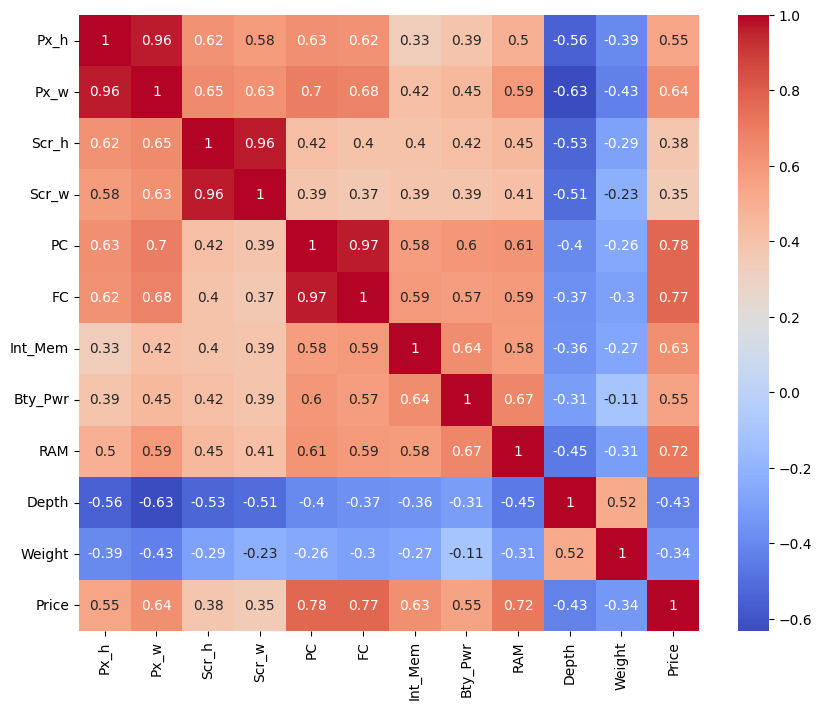

In [ ]:
corr = df.select_dtypes(include=np.number).corr()
print(corr)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

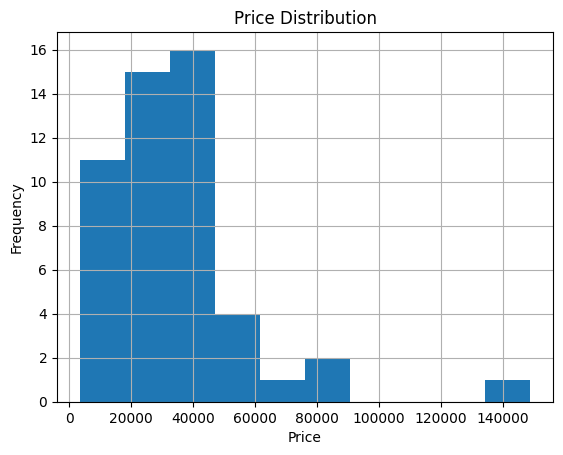

In [ ]:
df['Price'].hist(bins=10)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Price Distribution")
plt.show()

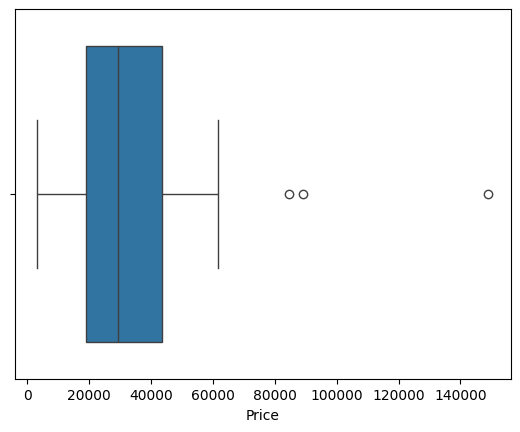

In [ ]:
sns.boxplot(x=df['Price'])
plt.show()

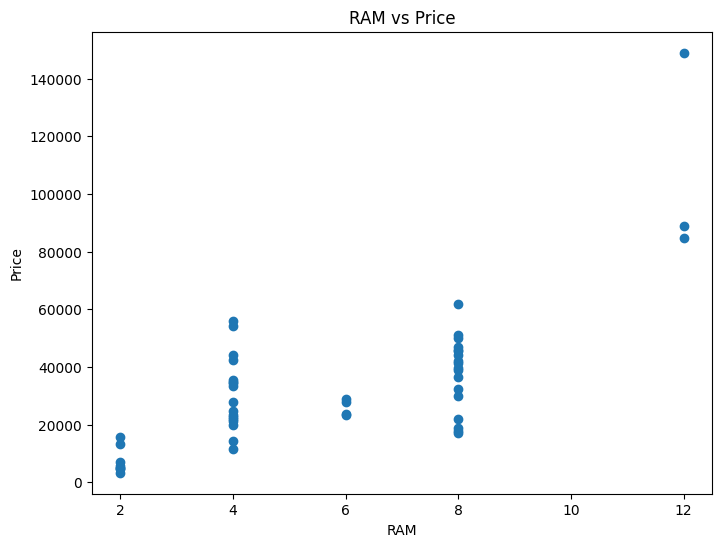

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['RAM'], df['Price'])
plt.xlabel("RAM")
plt.ylabel("Price")
plt.title("RAM vs Price")
plt.show()

In [ ]:
print(df.groupby('Blue')['Price'].mean())
print(df.groupby('Wi_Fi')['Price'].mean())

Blue
no     25596.304348
yes    40778.814815
Name: Price, dtype: float64
Wi_Fi
no     15705.000000
yes    37240.547619
Name: Price, dtype: float64


In [ ]:
le = LabelEncoder()

for col in ['Blue','Wi_Fi','Tch_Scr','Ext_Mem']:
    df[col] = le.fit_transform(df[col])


In [ ]:
df = df.drop('PID', axis=1)


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
pred=model.predict(X_test)

In [ ]:
print("R2 Score:", r2_score(y_test,pred))
print("MAE:", mean_absolute_error(y_test,pred))

R2 Score: 0.3467906864967918
MAE: 13037.346000000003


This model uses Random Forest Regression to predict mobile phone price based on specifications like RAM, battery, camera, and memory.
Categorical values are converted into numbers for training.
The data is split into training and testing sets.
The model learns patterns from the training data and predicts price on unseen data.
Performance is measured using R² score and MAE.
